# PALM Adaptation on IDRiD (RETFound-DINOv2)
PALM adapts on every batch using parameter-selection with KL divergence loss and consistency regularization.

In [1]:
import torch
torch.cuda.empty_cache()

In [2]:
import sys, os; sys.path.insert(0, os.getcwd())
import os, sys
_d = os.getcwd()
PROJECT_ROOT = None
while _d != os.path.dirname(_d):
    if os.path.exists(os.path.join(_d, 'setup.py')):
        PROJECT_ROOT = _d
        break
    _d = os.path.dirname(_d)
if PROJECT_ROOT is None:
    for _p in ['/kaggle/working/medical_CTTA', '/content/medical_CTTA']:
        if os.path.isdir(_p):
            PROJECT_ROOT = _p
            break
if PROJECT_ROOT and PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from src.env import init
init()

from src.config import load_config

In [3]:
config = load_config('configs/method/palm/idrid.yaml')

print('Dataset:', config.target_dataset.name)
print('Method:', config.ctta.method)
print('Mode: percentile selection')
print('Output:', config.output_dir)

# RETFound weights are gated behind HuggingFace; require a token.
assert config.model.name == 'retfound'
if not os.environ.get('HF_TOKEN'):
    import getpass
    token = getpass.getpass('Enter your HuggingFace token (hf_...): ')
    os.environ['HF_TOKEN'] = token
    print('HF_TOKEN set')

Dataset: idrid
Method: palm
Mode: percentile selection
Output: ./outputs/palm/idrid/
HF_TOKEN set


In [4]:
from src.evaluation.runner import CTTARunner

runner = CTTARunner(config)
results = runner.run()

2026-08-03 20:04:17,856 - src.evaluation.runner.single - INFO - Starting CTTA adaptation on dataset: idrid
2026-08-03 20:04:22,211 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/YukunZhou/RETFound_dinov2_meh/resolve/main/RETFound_dinov2_meh.pth "HTTP/1.1 302 Found"
2026-08-03 20:04:28,534 - src.models.retfound - INFO - Extracted state_dict from DINOv2 'teacher' key
2026-08-03 20:04:28,535 - src.models.retfound - INFO - Stripped 'backbone.' prefix from 359 state dict keys
2026-08-03 20:04:28,536 - src.models.retfound - INFO - RETFound checkpoint cached in CPU RAM
2026-08-03 20:04:28,668 - src.models.retfound - INFO - Feature normalization ENABLED in forward() (required for prototype classifier)
2026-08-03 20:04:29,351 - src.evaluation.runner.base - INFO - Loaded RETFound pretrained weights
2026-08-03 20:05:08,395 - src.evaluation.runner.base - INFO - Prototype weights scaled by T=50.0
2026-08-03 20:05:08,398 - src.evaluation.runner.base - INFO - Prototype classifier initiali

Adapting to idrid:   0%|          | 0/7 [00:00<?, ?it/s]

2026-08-03 20:05:32,182 - src.evaluation.runner.single - INFO -   Adapt step 0: loss=10.2399, entropy=1.5612, conf_samples=6, selected_mass=12,608,517/25,467,909 (49.5%)


Adapting to idrid:  14%|█▍        | 1/7 [00:13<01:22, 13.76s/it, acc=0.3125, adaptations=1]

2026-08-03 20:05:43,087 - src.evaluation.runner.single - INFO -   Adapt step 1: loss=6.9239, entropy=1.0678, conf_samples=5, selected_mass=12,608,517/25,467,909 (49.5%)


...

Adapting to idrid:  86%|████████▌ | 6/7 [01:08<00:11, 11.12s/it, acc=0.0625, adaptations=6]

2026-08-03 20:06:31,981 - src.evaluation.runner.single - INFO -   Adapt step 6: loss=2.1949, entropy=0.3990, conf_samples=4, selected_mass=12,608,517/25,467,909 (49.5%)


Adapting to idrid: 100%|██████████| 7/7 [01:12<00:00, 10.43s/it, acc=0.0000, adaptations=7]

2026-08-03 20:06:32,348 - src.evaluation.runner.single - INFO - Evaluating after adaptation on idrid


2026-08-03 20:06:40,969 - src.adapters.palm - WARNING - fallback: QWK 0.5307->0.0000, acc 0.4272->0.1262
2026-08-03 20:06:40,999 - src.evaluation.runner.single - WARNING - Fallback: post QWK 0.0000 < baseline 0.5307. Reverting to source weights.
2026-08-03 20:06:49,841 - src.evaluation.runner.single - INFO - Post-fallback QWK: 0.5307
2026-08-03 20:06:49,843 - src.evaluation.runner.single - INFO - Post-adaptation QWK: 0.5307
2026-08-03 20:06:49,844 - src.evaluation.runner.single - INFO - Adaptations: 7/7
2026-08-03 20:06:49,904 - src.evaluation.runner.base - INFO - Results saved to outputs/palm/idrid/ctta_results.json


In [5]:
print('=== Results ===')
print(f'Baseline QWK:        {results["baseline_metrics"]["qwk"]:.4f}')
print(f'Baseline Accuracy:   {results["baseline_metrics"]["overall_accuracy"]*100:.2f}%')
print(f'Post-adapt QWK:      {results["final_metrics"]["qwk"]:.4f}')
print(f'Post-adapt Accuracy: {results["final_metrics"]["overall_accuracy"]*100:.2f}%')
dr = results['domain_result']
print(f'Adaptations:          {dr["num_adaptations"]}/{dr["total_batches"]}')
print(f'Adaptation rate:      {results.get("adaptation_rate", 0)*100:.2f}%')

gap = results['final_metrics']['qwk'] - results['baseline_metrics']['qwk']
print(f'QWK change:           {gap:+.4f}')
acc_gap = results['final_metrics']['overall_accuracy'] - results['baseline_metrics']['overall_accuracy']
print(f'Accuracy change:      {acc_gap*100:+.2f}%')

=== Results ===
Baseline QWK:        0.5307
Baseline Accuracy:   42.72%
Post-adapt QWK:      0.5307
Post-adapt Accuracy: 42.72%
Adaptations:          7/7
Adaptation rate:      100.00%
QWK change:           +0.0000
Accuracy change:      +0.00%


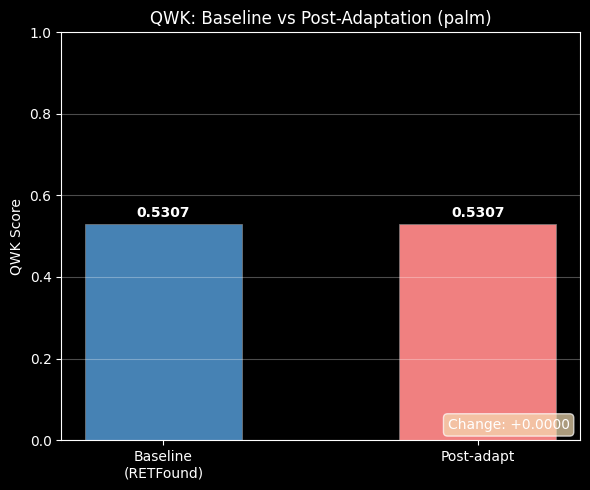

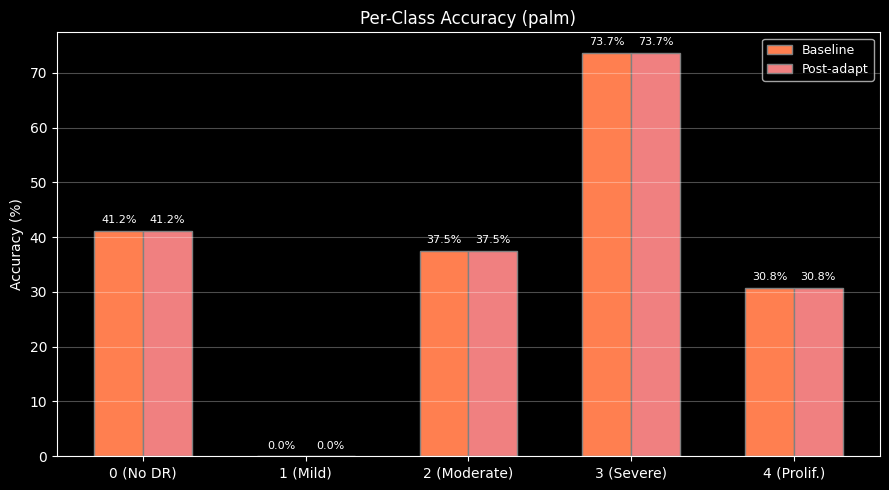

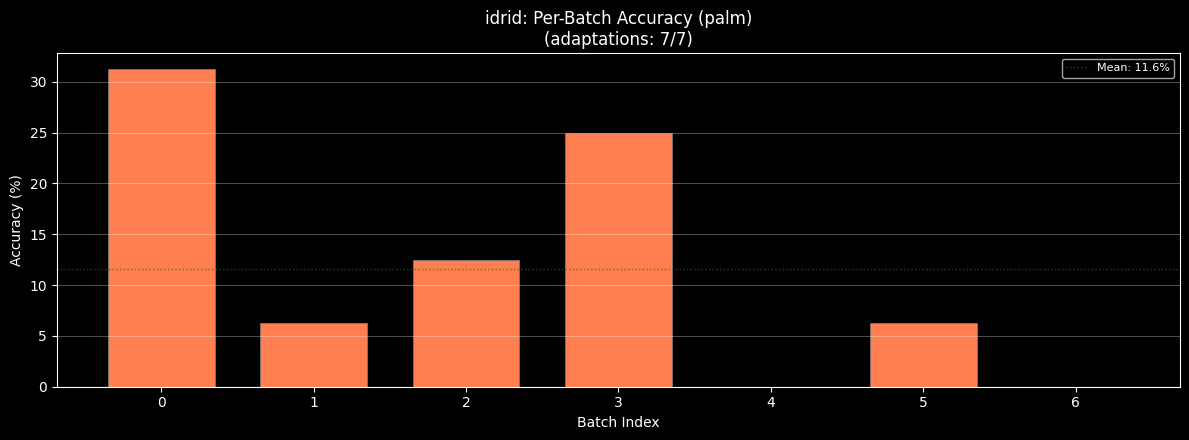

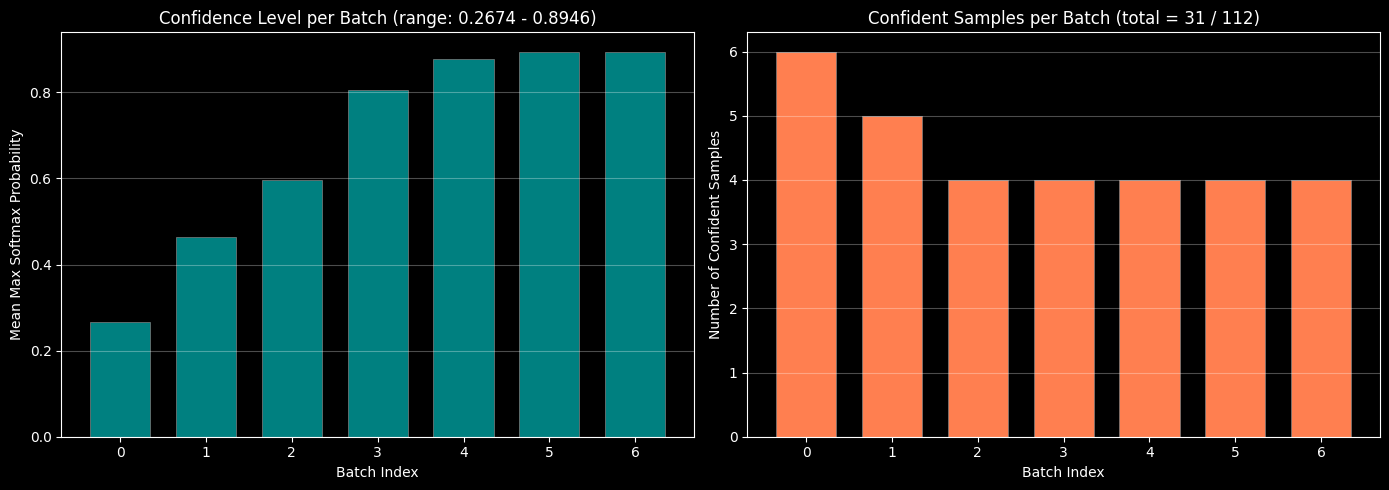

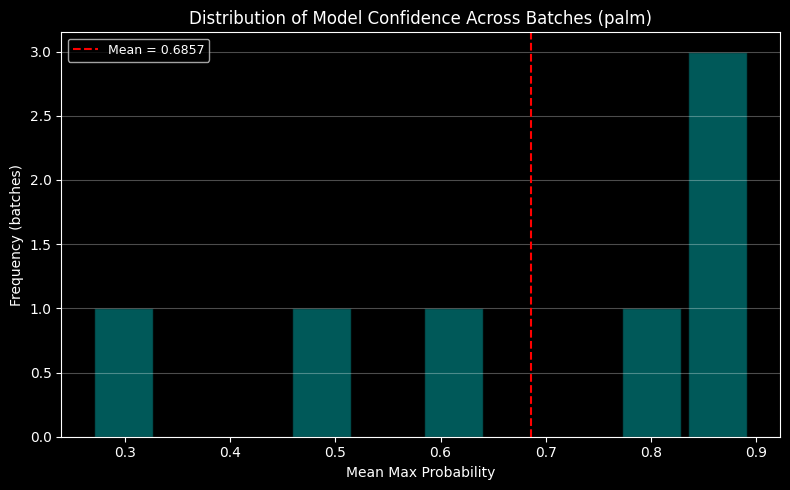

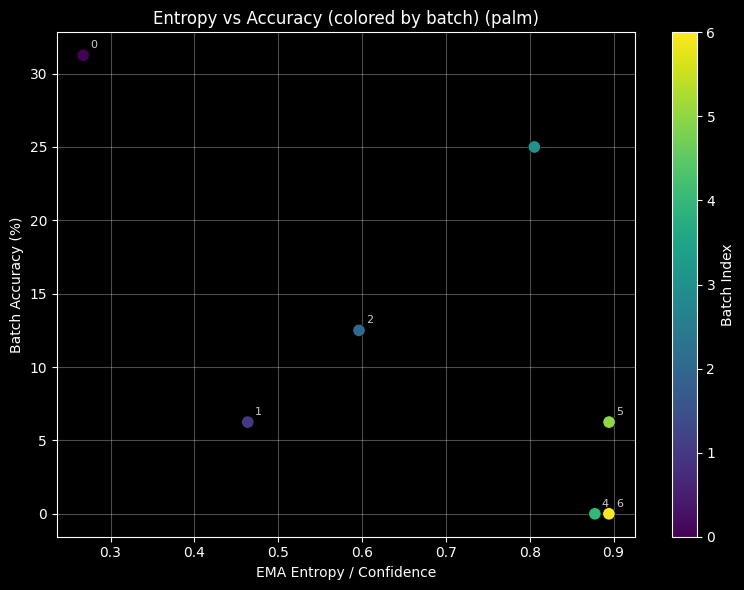

====================== CTTA Results (palm) ======================
Baseline QWK:       0.5307
Post-adapt QWK:     0.5307
Adaptations:        7/7
Adaptation rate:    100.00%
QWK change:         +0.0000
Mean batch acc:     11.6%


In [6]:
from src.viz import (
    get_domain_data, plot_qwk_bar, plot_per_batch_accuracy,
    plot_adaptation_metrics, plot_confidence_distribution,
    plot_entropy_vs_accuracy, print_summary_table, plot_per_class_accuracy as plot_pca,
)

import json
from pathlib import Path

plots_dir = Path(config.output_dir) / 'plots'
plots_dir.mkdir(exist_ok=True)

with open(Path(config.output_dir) / 'ctta_results.json') as f:
    results = json.load(f)

dr = results['domain_result']
method = results.get("method", "")

plot_qwk_bar(results, plots_dir, method_name=method)
plot_pca(results, dr, plots_dir, method_name=method)
plot_per_batch_accuracy(dr, None, plots_dir, method_name=method)
plot_adaptation_metrics(dr['adaptation_steps'], plots_dir)
plot_confidence_distribution(dr['adaptation_steps'], plots_dir, method_name=method)
plot_entropy_vs_accuracy(dr['adaptation_steps'], dr['batch_metrics'], plots_dir, method_name=method)
print_summary_table(results, method_name=method)